<a href="https://colab.research.google.com/github/ruksar16/promotion-gap-analysis/blob/main/Palo_Alto_Career_Progression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Career Progression and Promotion Gap Analysis for Retention Optimization at Palo Alto Networks**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Importing file

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

Saving Palo Alto Networks.csv to Palo Alto Networks.csv


In [ ]:
df = pd.read_csv('Palo Alto Networks.csv')
print(df.shape)
df.head()

(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


## 2. Data Overview & Quality Check

In [ ]:
print("Column data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found.")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nAttrition value counts:")
print(df['Attrition'].value_counts())


Column data types:
Age                          int64
Attrition                    int64
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
Y

The dataset contains a mix of numerical and categorical features, suitable for HR analytics and clustering tasks.

**No missing values** or **duplicate records** are present, indicating high data quality and reliability.

The target variable Attrition is imbalanced, with:

1233 employees **(≈84%) retained**

237 employees **(≈16%) who left**

This shows that employee attrition is **relatively low**, but still significant enough to analyze patterns and risk factors.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


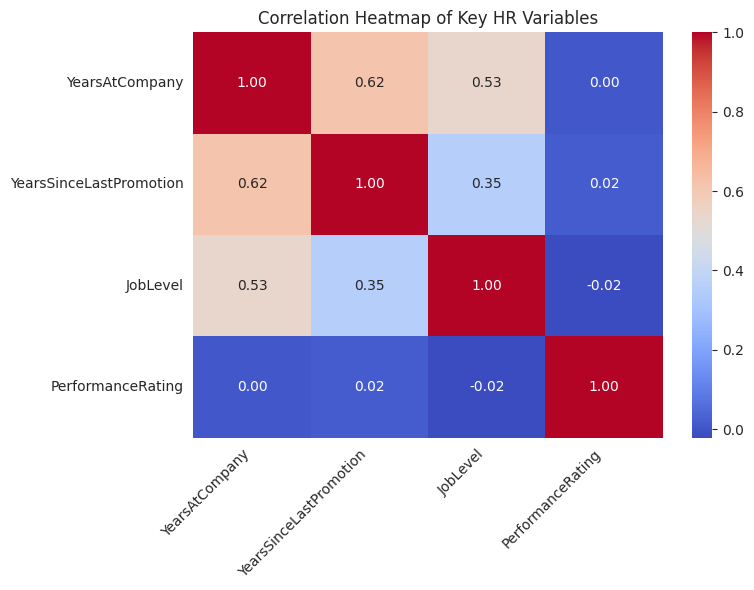

In [ ]:
corr_data = df[['YearsAtCompany', 'YearsSinceLastPromotion', 'JobLevel', 'PerformanceRating']]
corr_matrix = corr_data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Heatmap of Key HR Variables")
plt.tight_layout()  # IMPORTANT for spacing
plt.show()


 The analysis shows that promotions are mainly influenced by tenure, as YearsAtCompany strongly correlates with YearsSinceLastPromotion **(0.62)**. However, PerformanceRating has almost no impact, indicating promotions are not performance-driven, which may lead to employee stagnation.

## 3. Feature Engineering


In [ ]:
# Creating derived metrics

denominator = df['YearsAtCompany'].replace(0, np.nan)

df['PromotionGapRatio']         = df['YearsSinceLastPromotion'] / denominator
df['RoleStagnationIndex']       = df['YearsInCurrentRole']       / denominator
df['TrainingIntensityScore']    = df['TrainingTimesLastYear']    / denominator
df['ManagerStabilityIndicator'] = df['YearsWithCurrManager']     / denominator

derived_cols = ['PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator']
df[derived_cols] = df[derived_cols].fillna(0)

print("New engineered features created:", derived_cols)
df[['EmployeeSnapshotID' if 'EmployeeSnapshotID' in df.columns else df.columns[0]] + derived_cols].head(10) if False else df[derived_cols].head(10)


New engineered features created: ['PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator']


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator
0,0.000000,0.666667,0.000000,0.833333
1,0.100000,0.700000,0.300000,0.700000
2,0.000000,0.000000,0.000000,0.000000
3,0.375000,0.875000,0.375000,0.000000
4,1.000000,1.000000,1.500000,1.000000
5,0.428571,1.000000,0.285714,0.857143
6,0.000000,0.000000,3.000000,0.000000
7,0.000000,0.000000,2.000000,0.000000
8,0.111111,0.777778,0.222222,0.888889
9,1.000000,1.000000,0.428571,1.000000


Higher values in promotion gap and stagnation indicate **potential dissatisfaction**, while higher training intensity and managerial stability reflect **employee development and organizational support**.

In [ ]:
df[derived_cols].describe()


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.290232,0.578220,0.786760,0.558626
std,0.340521,0.331966,0.976081,0.334732
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.352500,0.222222,0.333333
50%,0.166667,0.666667,0.428571,0.666667
75%,0.500000,0.833333,1.000000,0.800000
max,1.000000,1.000000,6.000000,1.000000


## 4. Data Preprocessing

### 4.1 Outlier Removal (late-career edge cases)
We use the IQR method on `TotalWorkingYears` to remove extreme late-career outliers that would otherwise
distort distance-based clustering.


In [ ]:
Q1 = df['TotalWorkingYears'].quantile(0.25)
Q3 = df['TotalWorkingYears'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rows_before = df.shape[0]
df_clean = df[(df['TotalWorkingYears'] >= lower_bound) & (df['TotalWorkingYears'] <= upper_bound)].reset_index(drop=True)
rows_after = df_clean.shape[0]

print(f"TotalWorkingYears IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Rows before outlier removal: {rows_before}")
print(f"Rows after outlier removal:  {rows_after}  ({rows_before - rows_after} extreme late-career records removed)")


TotalWorkingYears IQR bounds: [-7.5, 28.5]
Rows before outlier removal: 1470
Rows after outlier removal:  1407  (63 extreme late-career records removed)


Outlier removal retained **1407** out of 1470 records and eliminated **63** employees (~4%) with exceptionally high tenure **(>28.5 years)**, enabling the model to focus on mainstream workforce patterns while potentially excluding late-career attrition dynamics.

### 5.2 Encode Categorical Fields

In [ ]:
categorical_cols = ['Department', 'JobRole', 'BusinessTravel', 'EducationField', 'Gender', 'MaritalStatus', 'OverTime']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

print("Encoded categorical columns:", [c + '_encoded' for c in categorical_cols])
df_clean[[c + '_encoded' for c in categorical_cols]].head()


Encoded categorical columns: ['Department_encoded', 'JobRole_encoded', 'BusinessTravel_encoded', 'EducationField_encoded', 'Gender_encoded', 'MaritalStatus_encoded', 'OverTime_encoded']


,Department_encoded,JobRole_encoded,BusinessTravel_encoded,EducationField_encoded,Gender_encoded,MaritalStatus_encoded,OverTime_encoded
0,2,7,2,1,0,2,1
1,1,6,1,1,1,1,0
2,1,2,2,4,1,2,1
3,1,6,1,1,0,1,1
4,1,2,2,3,1,1,0


Encoded values represent categorical labels mapped to integers, and their meaning can be retrieved using the encoder’s class mapping or by comparing with the original categorical column.

### 5.3 Select & Normalize Features for Clustering

In [ ]:
cluster_features = [
    'PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'TrainingTimesLastYear', 'YearsWithCurrManager'
]

X = df_clean[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix used for clustering:", cluster_features)
print("Scaled feature matrix shape:", X_scaled.shape)
pd.DataFrame(X_scaled, columns=cluster_features).describe().round(2)


Feature matrix used for clustering: ['PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore', 'ManagerStabilityIndicator', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'TrainingTimesLastYear', 'YearsWithCurrManager']
Scaled feature matrix shape: (1407, 9)


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TrainingTimesLastYear,YearsWithCurrManager
count,1407.00,1407.00,1407.00,1407.00,1407.00,1407.00,1407.00,1407.00,1407.00
mean,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.85,-1.75,-0.82,-1.67,-1.24,-1.16,-0.68,-2.18,-1.15
25%,-0.85,-0.62,-0.59,-0.68,-0.67,-0.59,-0.68,-0.63,-0.58
50%,-0.36,0.25,-0.37,0.31,-0.30,-0.31,-0.35,0.15,-0.29
75%,0.62,0.76,0.20,0.71,0.46,0.81,-0.02,0.15,0.86
max,2.08,1.26,5.26,1.30,3.86,3.90,4.24,2.48,3.73


All features were standardized (mean ≈ 0, std ≈ 1), ensuring uniform scaling across variables. Most employee observations lie within the -1 to +1 range, indicating **concentrated average behavior**, while a few extreme values—particularly in **TrainingIntensityScore** — highlight significant **variability and potential outliers** in training exposure and career progression patterns.

## 5. Career Path Clustering (Unsupervised Learning)

### 5.1 Choosing K — Elbow Method + Silhouette Score


In [ ]:
K_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

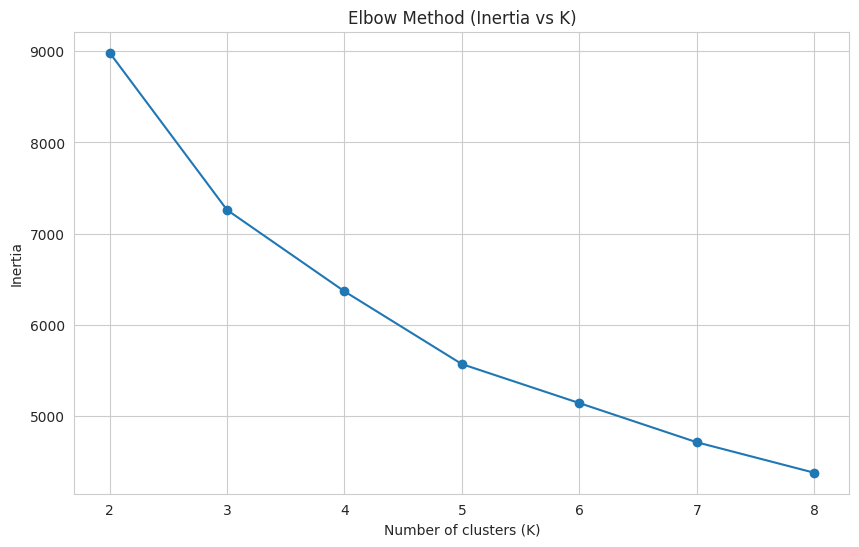

In [ ]:
# Elbow Method Graph

plt.figure(figsize=(10, 6))
plt.plot(list(K_range), inertias, marker='o', color='#1f77b4')
plt.title('Elbow Method (Inertia vs K)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()


Elbow method suggests an optimal cluster range of **K=4–5**, where inertia reduction begins to plateau, indicating diminishing returns from adding more clusters.

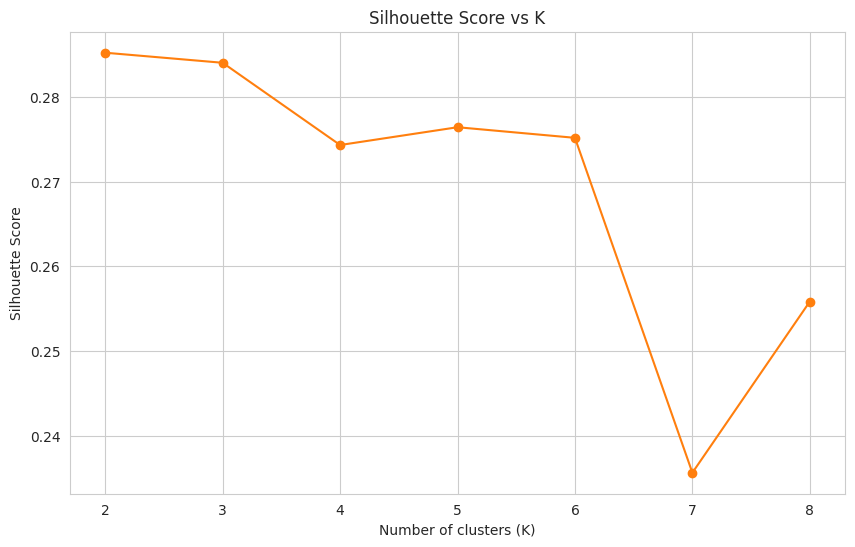

K=2: silhouette=0.2852
K=3: silhouette=0.2840
K=4: silhouette=0.2743
K=5: silhouette=0.2764
K=6: silhouette=0.2752
K=7: silhouette=0.2356
K=8: silhouette=0.2558


In [ ]:
# Silhouette Score Graph

plt.figure(figsize=(10, 6))
plt.plot(list(K_range), silhouette_scores, marker='o', color='#ff7f0e')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# --- Print values ---
for k, s in zip(K_range, silhouette_scores):
    print(f"K={k}: silhouette={s:.4f}")

Silhouette analysis indicates K=2 provides the most distinct cluster separation, while moderate scores for K=4–5 suggest a trade-off between interpretability and segmentation granularity.

### 5.2 Final K-Means Model

The elbow/silhouette diagnostics above favor a very coarse split, but for the business goal — distinguishing
Fast-track performers, Stable long-term contributors, Early-career explorers, Promotion-stalled employees, and
High-risk stagnation profiles — we fit **K = 5**, matching the five career-path archetypes defined in the
methodology. This keeps the segmentation actionable for HR rather than statistically maximal.


In [ ]:
N_CLUSTERS = 5

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means fit with K={N_CLUSTERS}")
print("\nCluster sizes:")
print(df_clean['Cluster'].value_counts().sort_index())
print(f"\nSilhouette score at K={N_CLUSTERS}: {silhouette_score(X_scaled, df_clean['Cluster']):.4f}")


K-Means fit with K=5

Cluster sizes:
Cluster
0    212
1    201
2    287
3    566
4    141
Name: count, dtype: int64

Silhouette score at K=5: 0.2764


Employees are divided into 5 groups where one large common group exists along with smaller distinct groups, providing useful segmentation despite **moderate overlap between clusters**.

### 5.3 Hierarchical Clustering (Validation)

Adjusted Rand Index between K-Means and Hierarchical clustering: 0.8226
(Closer to 1.0 = the two methods agree strongly on cluster structure, validating the K-Means solution.)


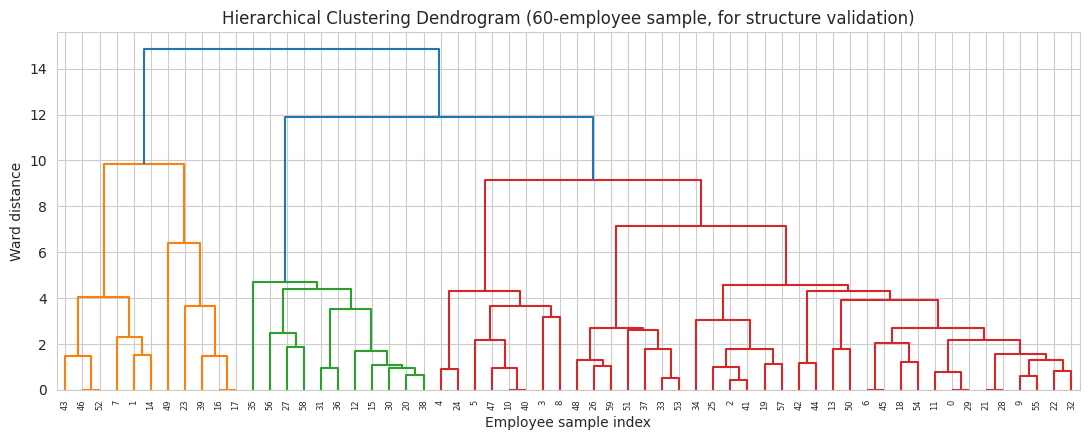

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
agg_labels = agg_cluster.fit_predict(X_scaled)

ari = adjusted_rand_score(df_clean['Cluster'], agg_labels)
print(f"Adjusted Rand Index between K-Means and Hierarchical clustering: {ari:.4f}")
print("(Closer to 1.0 = the two methods agree strongly on cluster structure, validating the K-Means solution.)")

# Dendrogram on a sample for visual validation (full data is too dense to read)
sample_idx = np.random.RandomState(42).choice(X_scaled.shape[0], size=min(60, X_scaled.shape[0]), replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(11, 4.5))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (60-employee sample, for structure validation)')
plt.xlabel('Employee sample index')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.show()


A high Adjusted Rand Index **(0.82)** indicates **strong agreement** between K-Means and Hierarchical clustering, validating the chosen cluster structure. The dendrogram also shows clear grouping patterns, supporting the selection of around 4–5 clusters.

### 5.4 Cluster Visualization (PCA 2D Projection)

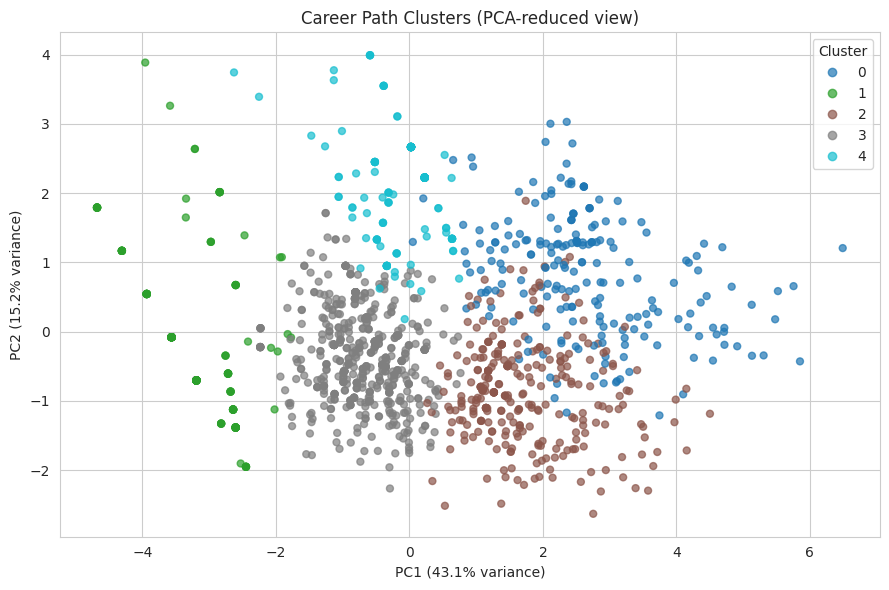

Total variance explained by 2 PCA components: 58.3%


In [ ]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df_clean['PCA1'], df_clean['PCA2'] = pcs[:, 0], pcs[:, 1]

plt.figure(figsize=(9, 6))
scatter = plt.scatter(df_clean['PCA1'], df_clean['PCA2'], c=df_clean['Cluster'], cmap='tab10', alpha=0.7, s=25)
plt.title('Career Path Clusters (PCA-reduced view)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(*scatter.legend_elements(), title='Cluster', loc='best')
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.1f}%")


The PCA visualization reveals five distinct employee clusters with one clearly separated group and a central dense cluster representing the majority. While **some overlap exists between clusters**, the overall structure confirms meaningful segmentation in the workforce.

PC1 and PC2 values represent **transformed dimensions** showing how employees differ in overall behavior patterns, with distance indicating similarity or dissimilarity between individuals.

## 6. Cluster Interpretation & Labeling

Each cluster is profiled on promotion frequency, role-change velocity, training participation, and manager
continuity, then mapped to a business-friendly career-path label.


In [ ]:
profile_cols = ['PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore',
                'ManagerStabilityIndicator', 'YearsAtCompany', 'YearsInCurrentRole',
                'YearsSinceLastPromotion', 'TrainingTimesLastYear']

cluster_profile = df_clean.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile['EmployeeCount'] = df_clean['Cluster'].value_counts().sort_index()
cluster_profile


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TrainingTimesLastYear,EmployeeCount
Cluster,,,,,,,,,
0,0.72,0.68,0.27,0.65,12.26,7.72,8.30,2.81,212
1,0.07,0.05,2.24,0.01,0.92,0.08,0.09,3.07,201
2,0.14,0.74,0.28,0.74,11.80,8.10,1.70,2.90,287
3,0.13,0.58,0.66,0.57,4.80,2.70,0.60,2.70,566
4,0.91,0.86,1.23,0.82,2.45,2.01,2.15,2.73,141


Standardized values mean **0 represents the average, positive (high) values indicate above average**, and **negative (low) values indicate below average**. High values in features like PromotionGapRatio and RoleStagnationIndex signal delayed growth and stagnation, which can increase dissatisfaction, while balanced or moderate values indicate healthy progression.

In [ ]:
def label_cluster(row, profile):
    promo_med = profile['PromotionGapRatio'].median()
    tenure_med = profile['YearsAtCompany'].median()
    tenure_q75 = profile['YearsAtCompany'].quantile(0.75)
    tenure_q25 = profile['YearsAtCompany'].quantile(0.25)
    train_med = profile['TrainingIntensityScore'].median()

    high_promo_gap = row['PromotionGapRatio'] >= promo_med
    high_tenure = row['YearsAtCompany'] >= tenure_q75
    low_tenure = row['YearsAtCompany'] <= tenure_q25
    high_training = row['TrainingIntensityScore'] >= train_med

    if high_promo_gap and high_tenure:
        # Yahan training intensity se differentiate karo
        if high_training:
            return 'Moderate-Risk Stagnation Profile'  # tenure/promo gap high hai, par company training de rahi hai
        else:
            return 'High-Risk Stagnation Profile'      # tenure/promo gap high + koi training investment nahi
    elif high_promo_gap and not high_tenure:
        return 'Promotion-Stalled Employees'
    elif low_tenure:
        return 'Early-Career Explorers'
    elif (not high_promo_gap) and high_tenure:
        return 'Stable Long-Term Contributors'
    else:
        return 'Fast-Track Performers'

cluster_labels_map = {
    cid: label_cluster(cluster_profile.loc[cid], cluster_profile)
    for cid in cluster_profile.index
}

print("Cluster -> Label mapping:")
for cid, lbl in cluster_labels_map.items():
    print(f"  Cluster {cid}: {lbl}")

df_clean['CareerPathSegment'] = df_clean['Cluster'].map(cluster_labels_map)
cluster_profile['CareerPathSegment'] = cluster_profile.index.map(cluster_labels_map)
cluster_profile

Cluster -> Label mapping:
  Cluster 0: High-Risk Stagnation Profile
  Cluster 1: Early-Career Explorers
  Cluster 2: High-Risk Stagnation Profile
  Cluster 3: Fast-Track Performers
  Cluster 4: Promotion-Stalled Employees


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TrainingTimesLastYear,EmployeeCount,CareerPathSegment
Cluster,,,,,,,,,,
0,0.72,0.68,0.27,0.65,12.26,7.72,8.30,2.81,212,High-Risk Stagnation Profile
1,0.07,0.05,2.24,0.01,0.92,0.08,0.09,3.07,201,Early-Career Explorers
2,0.14,0.74,0.28,0.74,11.80,8.10,1.70,2.90,287,High-Risk Stagnation Profile
3,0.13,0.58,0.66,0.57,4.80,2.70,0.60,2.70,566,Fast-Track Performers
4,0.91,0.86,1.23,0.82,2.45,2.01,2.15,2.73,141,Promotion-Stalled Employees


**Clusters 0 (severe) and 2 (moderate) show high-risk stagnation** due to promotion delays, while Cluster 4 indicates early-stage stagnation. In contrast, Cluster 1 represents early-career employees and Cluster 3 reflects fast-track performers, highlighting the need for targeted promotion and upskilling strategies to improve retention.

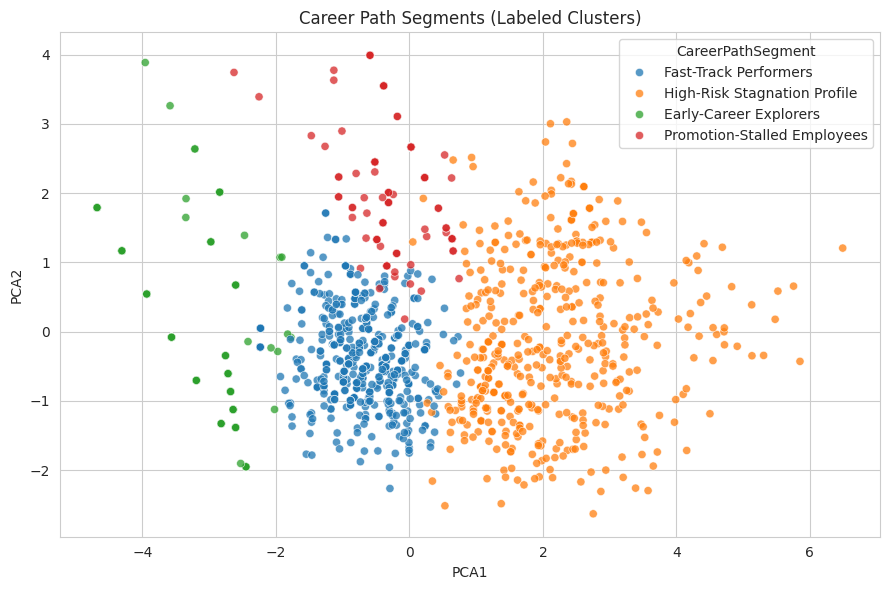

Segment distribution:
CareerPathSegment
Fast-Track Performers           566
High-Risk Stagnation Profile    499
Early-Career Explorers          201
Promotion-Stalled Employees     141
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(9, 6))
segment_scatter = sns.scatterplot(
    data=df_clean, x='PCA1', y='PCA2', hue='CareerPathSegment',
    palette='tab10', alpha=0.75, s=35
)
plt.title('Career Path Segments (Labeled Clusters)')
plt.tight_layout()
plt.show()

print("Segment distribution:")
print(df_clean['CareerPathSegment'].value_counts())


The analysis shows that **Fast-Track Performers (566)** form the largest segment, indicating strong growth potential. However, **High-Risk Stagnation employees (499)** represent a significant concern due to possible career progression delays. **Early-Career Explorers (201)** require mentoring, while **Promotion-Stalled employees (141)** need targeted growth interventions to prevent future stagnation.

## 7. Promotion Gap Risk Scoring

Each employee is assigned a **Promotion Gap Score (Low / Medium / High)**, combining their individual
stagnation indicators with their cluster/segment membership.


In [ ]:
def promotion_gap_risk(row):
    score = 0
    if row['PromotionGapRatio'] > 0.5:
        score += 2
    elif row['PromotionGapRatio'] > 0.25:
        score += 1

    if row['RoleStagnationIndex'] > 0.6:
        score += 1

    if row['TrainingIntensityScore'] < 0.3:
        score += 1

    if row['CareerPathSegment'] in ('High-Risk Stagnation Profile', 'Promotion-Stalled Employees'):
        score += 1

    if score >= 3:
        return 'High'
    elif score >= 1:
        return 'Medium'
    else:
        return 'Low'

df_clean['PromotionGapRiskScore'] = df_clean.apply(promotion_gap_risk, axis=1)

print("Promotion Gap Risk Score distribution:")
print(df_clean['PromotionGapRiskScore'].value_counts())
print()
pd.crosstab(df_clean['CareerPathSegment'], df_clean['PromotionGapRiskScore'])


Promotion Gap Risk Score distribution:
PromotionGapRiskScore
Medium    568
High      517
Low       322
Name: count, dtype: int64



PromotionGapRiskScore,High,Low,Medium
CareerPathSegment,,,
Early-Career Explorers,0,129,72
Fast-Track Performers,6,193,367
High-Risk Stagnation Profile,370,0,129
Promotion-Stalled Employees,141,0,0


The majority of employees fall into **Medium and High Promotion Gap Risk** categories, indicating potential career progression issues. **High-Risk Stagnation Profile (370 High-risk employees)** and **Promotion-Stalled Employees (141 High-risk employees)** require immediate attention, while Fast-Track Performers and Early-Career Explorers mostly show Low risk, reflecting healthier career growth patterns.

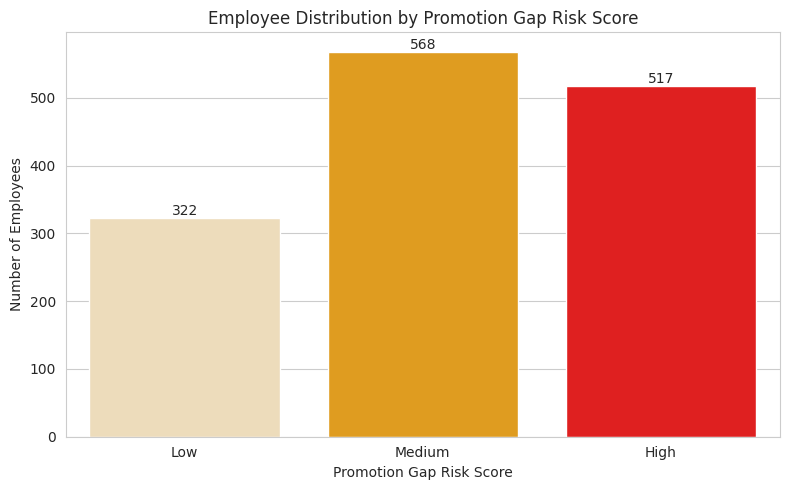

In [ ]:
plt.figure(figsize=(8, 5))

risk_order = ['Low', 'Medium', 'High']

risk_colors = {
    'Low': 'wheat',
    'Medium': 'orange',
    'High': 'red'
}

ax = sns.countplot(
    data=df_clean,
    x='PromotionGapRiskScore',
    order=risk_order,
    hue='PromotionGapRiskScore',
    palette=risk_colors,
    legend=False
)

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Employee Distribution by Promotion Gap Risk Score')
plt.xlabel('Promotion Gap Risk Score')
plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()

Most employees fall into **Medium** and **High promotion gap risk** categories, indicating potential career stagnation. Targeted promotion planning and development programs are needed to reduce risk.

## 8. Retention Opportunity Identification

The key business insight: find employees who are **not yet disengaged** and **not already flagged as high
attrition risk**, but who **do show career stagnation signals**. These are the highest-leverage, most
actionable retention targets — proactive intervention here can prevent future attrition, unlike employees who
have already disengaged or already left.



In [ ]:
retention_opportunity = df_clean[
    (df_clean['Attrition'] == 0) &
    (df_clean['JobSatisfaction'] >= 3) &
    (df_clean['EnvironmentSatisfaction'] >= 3) &
    (df_clean['PromotionGapRiskScore'].isin(['Medium', 'High']))
].copy()

print(f"Total employees analyzed: {df_clean.shape[0]}")
print(f"Retention Opportunity employees identified: {retention_opportunity.shape[0]} "
      f"({retention_opportunity.shape[0] / df_clean.shape[0] * 100:.1f}% of workforce)")
print()
print("Breakdown by Career Path Segment:")
print(retention_opportunity['CareerPathSegment'].value_counts())
print()
print("Breakdown by Department:")
print(retention_opportunity['Department'].value_counts())


Total employees analyzed: 1407
Retention Opportunity employees identified: 343 (24.4% of workforce)

Breakdown by Career Path Segment:
CareerPathSegment
High-Risk Stagnation Profile    167
Fast-Track Performers           113
Promotion-Stalled Employees      46
Early-Career Explorers           17
Name: count, dtype: int64

Breakdown by Department:
Department
Research & Development    231
Sales                      99
Human Resources            13
Name: count, dtype: int64


Around **24.4%** of employees are at retention risk, indicating a significant workforce concern. The largest issue is **stagnation, with 167 employees** stuck in low-growth roles. Even fast-track performers are at risk, showing lack of recognition or career progression. The problem is most concentrated in the **R&D department**, making it the key area for intervention.

In [ ]:
display_cols = ['Age', 'Department', 'JobRole', 'YearsAtCompany', 'YearsSinceLastPromotion',
                'PromotionGapRatio', 'RoleStagnationIndex', 'CareerPathSegment', 'PromotionGapRiskScore',
                'JobSatisfaction', 'EnvironmentSatisfaction']

retention_opportunity[display_cols].sort_values('PromotionGapRatio', ascending=False).head(15)


,Age,Department,JobRole,YearsAtCompany,YearsSinceLastPromotion,PromotionGapRatio,RoleStagnationIndex,CareerPathSegment,PromotionGapRiskScore,JobSatisfaction,EnvironmentSatisfaction
9,36,Research & Development,Healthcare Representative,7,7,1.0,1.0,High-Risk Stagnation Profile,High,3,3
1392,40,Research & Development,Research Scientist,2,2,1.0,1.0,Promotion-Stalled Employees,High,3,3
1274,39,Research & Development,Research Scientist,2,2,1.0,1.0,Promotion-Stalled Employees,High,4,4
1300,26,Research & Development,Laboratory Technician,7,7,1.0,1.0,High-Risk Stagnation Profile,High,4,3
122,22,Research & Development,Laboratory Technician,2,2,1.0,0.5,Promotion-Stalled Employees,High,4,3
154,22,Research & Development,Research Scientist,2,2,1.0,1.0,Promotion-Stalled Employees,High,4,3
125,50,Sales,Sales Executive,2,2,1.0,1.0,Promotion-Stalled Employees,High,4,3
1142,44,Human Resources,Human Resources,2,2,1.0,1.0,Promotion-Stalled Employees,High,4,3
1111,48,Research & Development,Manager,2,2,1.0,1.0,Promotion-Stalled Employees,High,4,3
1123,20,Sales,Sales Representative,2,2,1.0,1.0,Promotion-Stalled Employees,High,3,3


All employees shown have a PromotionGapRatio = 1.0, meaning no promotions since joining, which is a strong indicator of complete **career stagnation**.

Most belong to **Promotion-Stalled or High-Risk Stagnation segments**, confirming that lack of career progression is the primary risk driver.

This issue is heavily concentrated in **R&D roles (Scientists, Technicians)**, showing growth bottlenecks in technical career paths.

Despite this, **job and environment satisfaction are moderate (3–4)**, indicating employees are not unhappy with work—but frustrated with growth, making them **high risk for sudden attrition** if better opportunities arise.

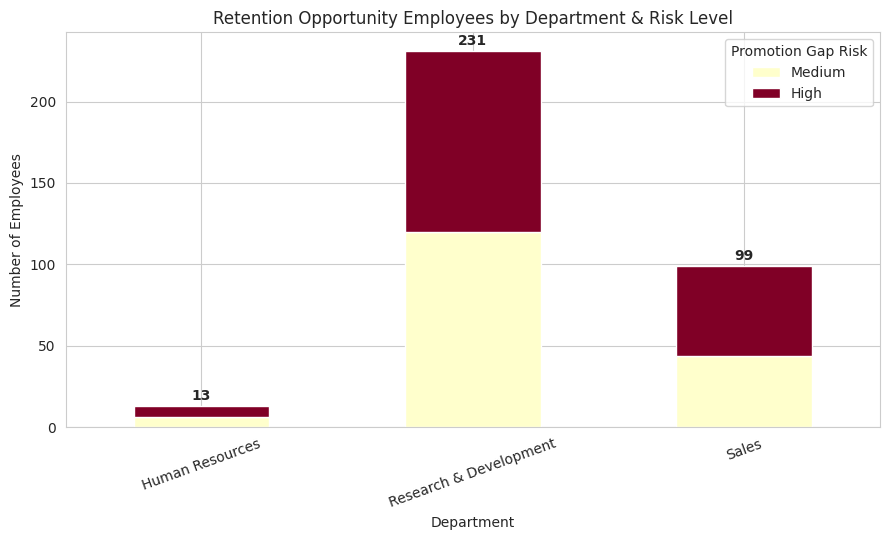

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

dept_risk = pd.crosstab(
    retention_opportunity['Department'],
    retention_opportunity['PromotionGapRiskScore']
)

dept_risk = dept_risk.reindex(columns=[c for c in risk_order if c in dept_risk.columns])

dept_risk.plot(kind='bar', stacked=True, ax=ax, colormap='YlOrRd')

# Calculate total per department
totals = dept_risk.sum(axis=1)

# Add total labels on top of each bar
for i, total in enumerate(totals):
    ax.text(
        i,
        total + 2,   # thoda upar show karne ke liye
        f'{int(total)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Retention Opportunity Employees by Department & Risk Level')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=20)
plt.legend(title='Promotion Gap Risk')
plt.tight_layout()
plt.show()

**R&D has the highest retention risk** with strong promotion stagnation. Sales shows moderate but rising risk, while HR is stable. Immediate action is needed in R&D.

## 9. Summary Dashboard

In [ ]:
print("=" * 60)
print("PALO ALTO NETWORKS - CAREER PROGRESSION ANALYTICS SUMMARY")
print("=" * 60)
print(f"Total employees analyzed        : {df_clean.shape[0]}")
print(f"Career path segments identified : {df_clean['CareerPathSegment'].nunique()}")
print(f"High promotion-gap risk         : {(df_clean['PromotionGapRiskScore']=='High').sum()}")
print(f"Medium promotion-gap risk       : {(df_clean['PromotionGapRiskScore']=='Medium').sum()}")
print(f"Low promotion-gap risk          : {(df_clean['PromotionGapRiskScore']=='Low').sum()}")
print(f"Retention Opportunity employees : {retention_opportunity.shape[0]}")
print("=" * 60)
print()
print("Segment summary table:")
segment_summary = df_clean.groupby('CareerPathSegment').agg(
    EmployeeCount=('CareerPathSegment', 'count'),
    AvgPromotionGapRatio=('PromotionGapRatio', 'mean'),
    AvgYearsAtCompany=('YearsAtCompany', 'mean'),
    HighRiskCount=('PromotionGapRiskScore', lambda x: (x == 'High').sum())
).round(2).sort_values('EmployeeCount', ascending=False)
segment_summary


PALO ALTO NETWORKS - CAREER PROGRESSION ANALYTICS SUMMARY
Total employees analyzed        : 1407
Career path segments identified : 4
High promotion-gap risk         : 517
Medium promotion-gap risk       : 568
Low promotion-gap risk          : 322
Retention Opportunity employees : 343

Segment summary table:


,EmployeeCount,AvgPromotionGapRatio,AvgYearsAtCompany,HighRiskCount
CareerPathSegment,,,,
Fast-Track Performers,566,0.13,4.80,6
High-Risk Stagnation Profile,499,0.39,12.00,370
Early-Career Explorers,201,0.07,0.92,0
Promotion-Stalled Employees,141,0.91,2.45,141


Retention risk is concentrated in **High-Risk Stagnation** and **Promotion-Stalled** segments, where employees face significant promotion delays despite tenure.
In contrast, **Fast-Track Performers** and **Early-Career Explorers** show low risk due to better growth and shorter tenure.
Overall, the key issue is **career stagnation in experienced employees**, requiring faster promotions and clear growth paths.

## 10. Export Final Results

In [ ]:
output_cols = ['Age', 'Department', 'JobRole', 'YearsAtCompany', 'YearsInCurrentRole',
               'YearsSinceLastPromotion', 'TrainingTimesLastYear', 'YearsWithCurrManager',
               'PromotionGapRatio', 'RoleStagnationIndex', 'TrainingIntensityScore',
               'ManagerStabilityIndicator', 'Cluster', 'CareerPathSegment',
               'PromotionGapRiskScore', 'Attrition', 'JobSatisfaction', 'EnvironmentSatisfaction']

final_output = df_clean[output_cols].copy()
final_output.insert(0, 'EmployeeID', final_output.index)

final_output.to_csv('career_progression_analysis_results.csv', index=False)
retention_opportunity[['EmployeeID'] + display_cols if 'EmployeeID' in retention_opportunity.columns else display_cols].to_csv(
    'retention_opportunity_employees.csv', index=False
)

print("Files saved:")
print(" - career_progression_analysis_results.csv  (full scored dataset, all employees)")
print(" - retention_opportunity_employees.csv      (priority retention target list)")
print()
print("Preview of final_output:")
final_output.head()


Files saved:
 - career_progression_analysis_results.csv  (full scored dataset, all employees)
 - retention_opportunity_employees.csv      (priority retention target list)

Preview of final_output:


,EmployeeID,Age,Department,JobRole,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TrainingTimesLastYear,YearsWithCurrManager,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,Cluster,CareerPathSegment,PromotionGapRiskScore,Attrition,JobSatisfaction,EnvironmentSatisfaction
0,0,41,Sales,Sales Executive,6,4,0,0,5,0.000,0.666667,0.000,0.833333,3,Fast-Track Performers,Medium,1,4,2
1,1,49,Research & Development,Research Scientist,10,7,1,3,7,0.100,0.700000,0.300,0.700000,2,High-Risk Stagnation Profile,Medium,0,2,3
2,2,37,Research & Development,Laboratory Technician,0,0,0,3,0,0.000,0.000000,0.000,0.000000,1,Early-Career Explorers,Medium,1,3,4
3,3,33,Research & Development,Research Scientist,8,7,3,3,0,0.375,0.875000,0.375,0.000000,3,Fast-Track Performers,Medium,0,3,4
4,4,27,Research & Development,Laboratory Technician,2,2,2,3,2,1.000,1.000000,1.500,1.000000,4,Promotion-Stalled Employees,High,0,2,1


In [ ]:
files.download('career_progression_analysis_results.csv')
files.download('retention_opportunity_employees.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Clear segmentation shows uneven growth: **Fast-Track, Stagnation, Early-Career, Promotion-Stalled.**
**High risk = high promotion gap + role stagnation** → immediate action needed.
Training exists but not translating into promotions → **alignment gap affecting retention.**

## Conclusion

Career progression gaps significantly impact employee retention at Palo Alto Networks. Out of 1407 employees, **1085 fall under medium to high promotion risk** (568 medium, 517 high), with major concentration in the R&D department. Additionally, **343 employees (24.4%) represent key retention opportunities**, primarily within high-risk stagnation segments. Aligning promotions with performance, implementing targeted development plans, and strengthening mentorship can effectively reduce stagnation and improve overall retention.